# 1. MaskClustering Output Exploration

In [1]:
import open3d as o3d
import json
from pathlib import Path
from glob import glob
import cv2
import networkx as nx
import os
from PIL import Image, ImageDraw
import numpy as np
import torch
import matplotlib.pyplot as plt
import images_processing as img_process
import caption_generator as cap
# pip install torch==2.4.0 transformers==4.46.2 numpy==1.25.0 pillow==10.3.0
# pip install flash-attn==2.7.0.post2 --no-build-isolation
# pip install transformers accelerate sentencepiece

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
output_path = 'data/scannetpp/data/0a7cc12c0e/output/object/scannetpp/object_dict.npy'
output = np.load(output_path, allow_pickle=True)

In [32]:
data = output.item()
print(f'There are totally {len(data)} objects in the scene.\n')
object_0 = data[9]
frame_ids = [frame for (frame, mask, score) in object_0['repre_mask_list']][:3]
mask_ids = [mask for (frame, mask, score) in object_0['repre_mask_list']][:3]
for frame, mask in zip(frame_ids, mask_ids):
    print(f'Frame {frame} -> Mask {mask}')

There are totally 325 objects in the scene.

Frame 890 -> Mask 27
Frame 990 -> Mask 44
Frame 300 -> Mask 4


In [4]:
image_path = 'data/scannetpp/data/0a7cc12c0e/iphone/rgb'
images = [Image.open(f'{image_path}/frame_{id:06d}.jpg') for id in frame_ids]

# mask_path = 'data/demo/scene0608_00/output/mask'
mask_path = 'data/scannetpp/data/0a7cc12c0e/output/mask'

masks = [
    Image.open(os.path.join(mask_path, f'frame_{frame_id:06d}.png')).convert('L')
    for frame_id in frame_ids
]

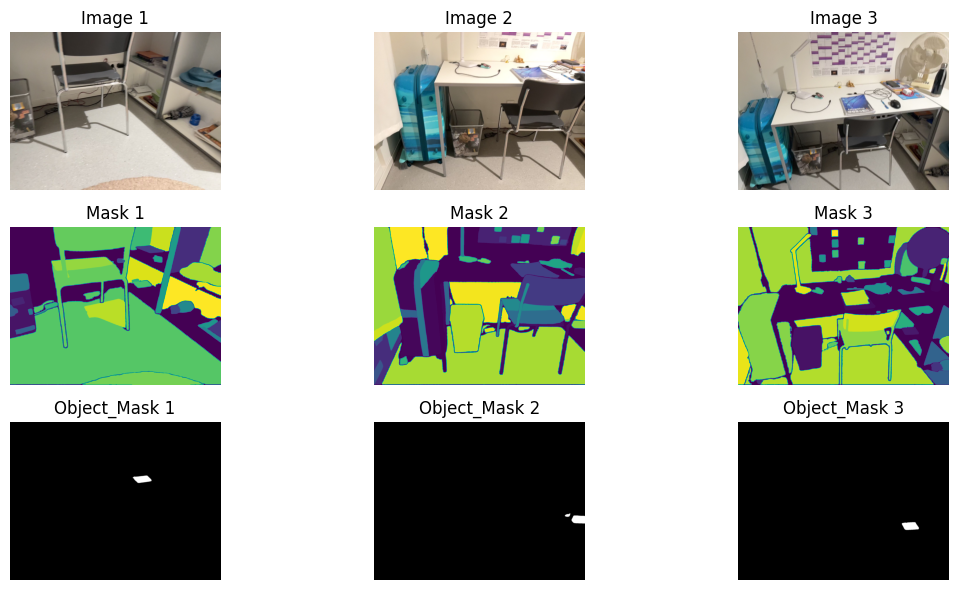

In [5]:
img_process.img_visualization(images=images, masks=masks, mask_ids=mask_ids, number_of_images=3)

# 2. Bounding Boxes of Objects

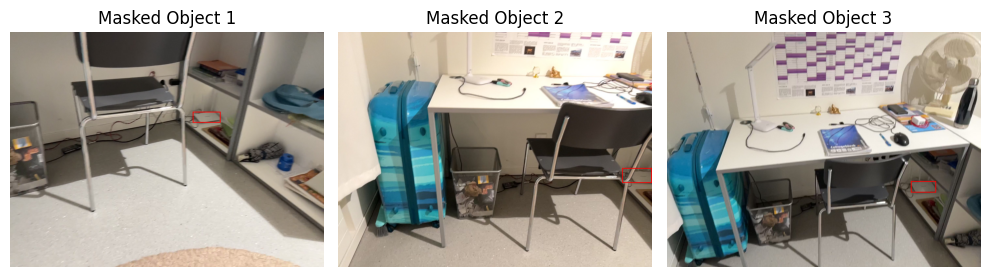

In [6]:
masked_images = []
for img, id, mask in zip(images, mask_ids, masks):
    binary_mask = (np.array(mask) == id).astype(np.uint8) * 255
    x_min, y_min, x_max, y_max = img_process.mask_to_bbox(binary_mask)
    bbox = (x_min, y_min, x_max, y_max)
    if len(masked_images) <= 5:
        masked_images.append(img_process.draw_bbox_on_image(img, bbox))
img_process.img_visualization(masked_images=masked_images, number_of_images=3)

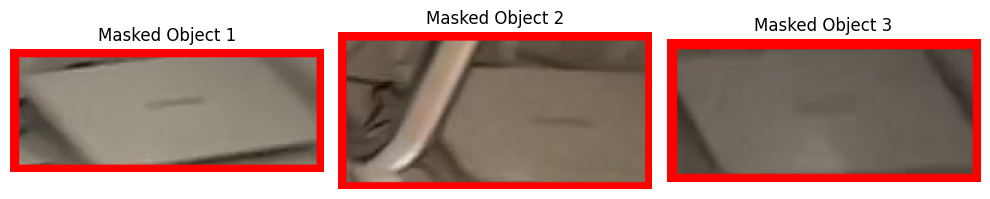

In [7]:
masked_images_padded = []
for img, id, mask in zip(images, mask_ids, masks):
    binary_mask = (np.array(mask) == id).astype(np.uint8) * 255
    x_min, y_min, x_max, y_max = img_process.mask_to_bbox(binary_mask)
    bbox = (x_min, y_min, x_max, y_max)
    img = img_process.draw_bbox_on_image(img, bbox)
    cropped_img = img_process.crop_with_padding(img, bbox, padding_ratio=0)
    if len(masked_images_padded) < 5:
        masked_images_padded.append(cropped_img)
img_process.img_visualization(masked_images=masked_images_padded)

# Object Level Captioning

In [13]:
import internVL
vlm = internVL.InternVL_VLM()

In [53]:
top5_images = masked_images_padded
pixel_values, num_patches_list = vlm.image_preprocess(top5_images)
categoryy = vlm.generate_caption(pixel_values=pixel_values,generation_type='object-category', num_patches_list=num_patches_list)
object_caption = vlm.generate_caption(pixel_values=pixel_values,generation_type='object-level', num_patches_list=num_patches_list)
object_surroudning = vlm.generate_caption(pixel_values=pixel_values,generation_type='object-surrounding', num_patches_list=num_patches_list)

print(f'Category: {categoryy}')
print(f'Object Caption: {object_caption}')
print(f'Object Surrounding: {object_surroudning}')

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Category: chair
Object Caption: The object is a sleek, rectangular electronic device with a minimalist design, featuring a smooth, matte finish and a subtle, thin line in the center, likely indicating a brand logo or design element.
Object Surrounding: This object is a white box with a simple design.  
It is positioned next to a piece of furniture, likely a chair or table.  
The box is situated on a flat surface, possibly a table or countertop.  
The box appears to be a storage or packaging item, possibly for a small appliance or device.


In [15]:
data[0].keys()

dict_keys(['point_ids', 'mask_list', 'repre_mask_list'])

Generating captions:   0%|          | 0/10 [00:00<?, ?it/s]

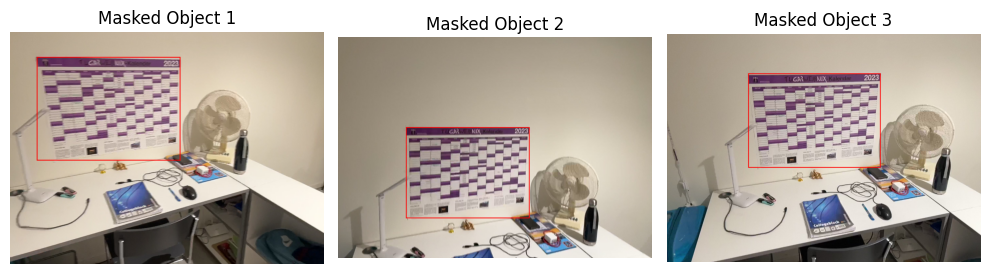

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:  10%|█         | 1/10 [00:06<00:55,  6.13s/it]

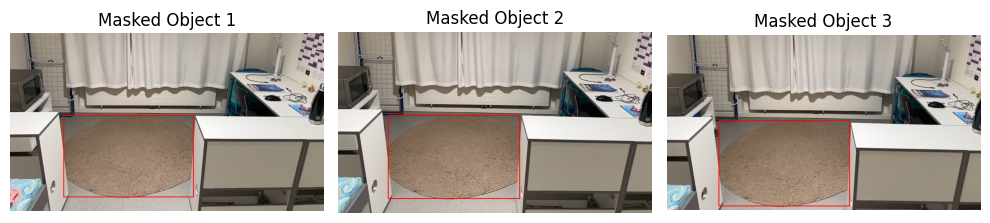

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:  20%|██        | 2/10 [00:10<00:40,  5.01s/it]

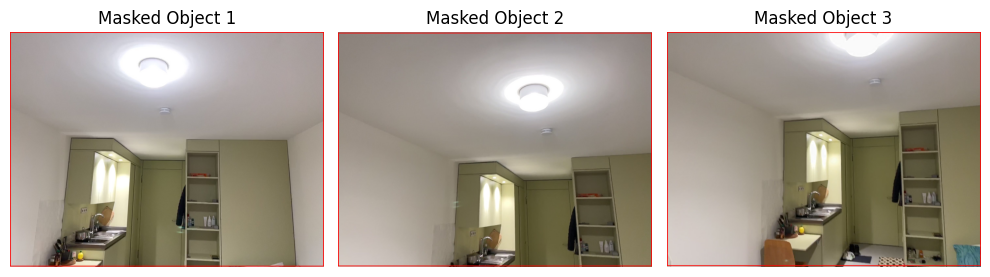

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:  30%|███       | 3/10 [00:16<00:38,  5.45s/it]

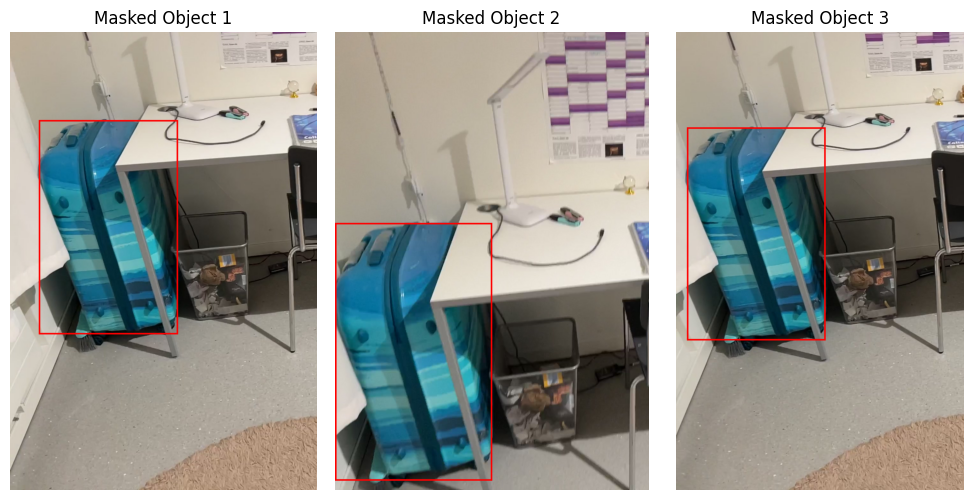

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:  40%|████      | 4/10 [00:20<00:28,  4.76s/it]

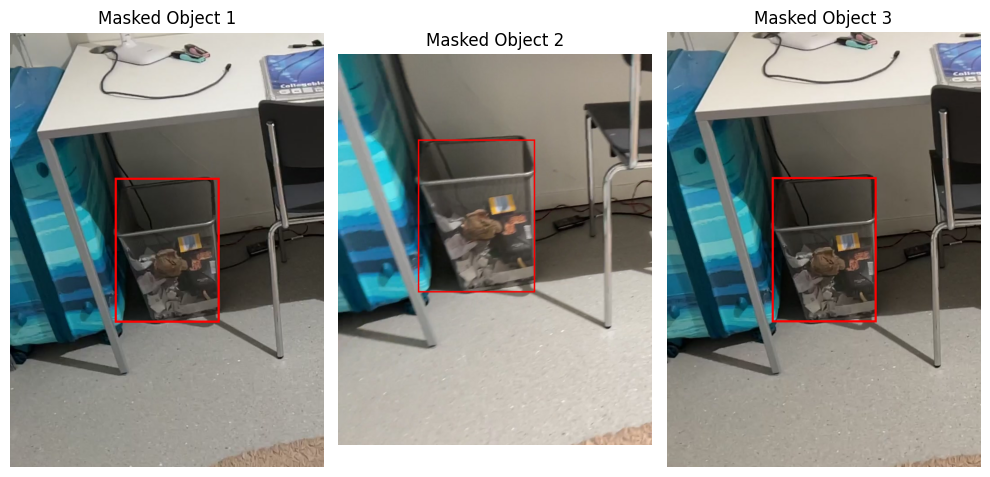

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:  50%|█████     | 5/10 [00:25<00:25,  5.09s/it]

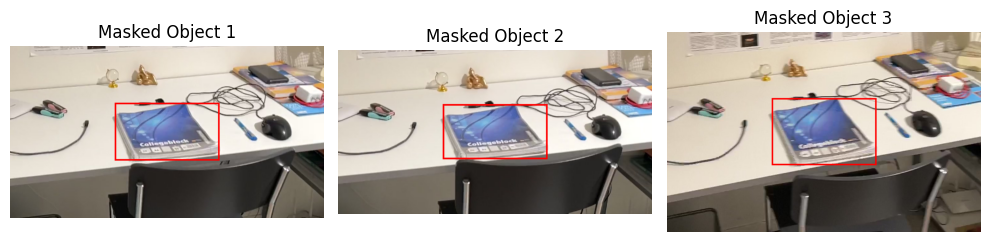

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:  60%|██████    | 6/10 [00:28<00:17,  4.43s/it]

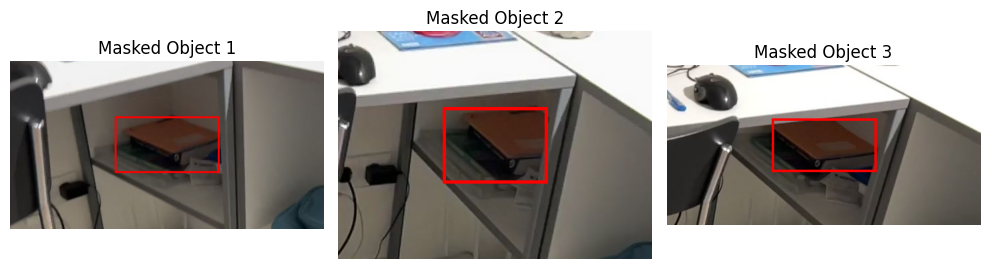

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:  70%|███████   | 7/10 [00:32<00:12,  4.13s/it]

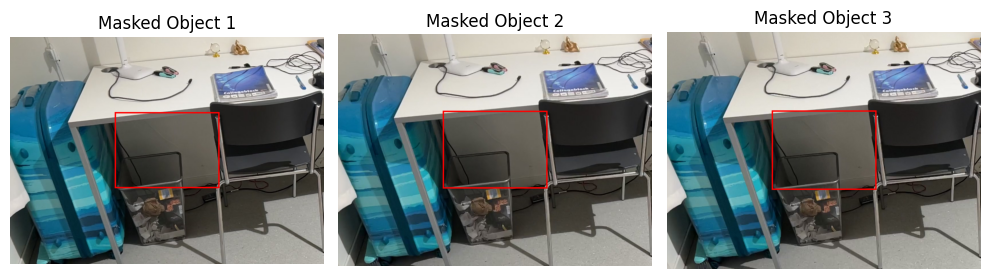

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:  80%|████████  | 8/10 [00:37<00:09,  4.55s/it]

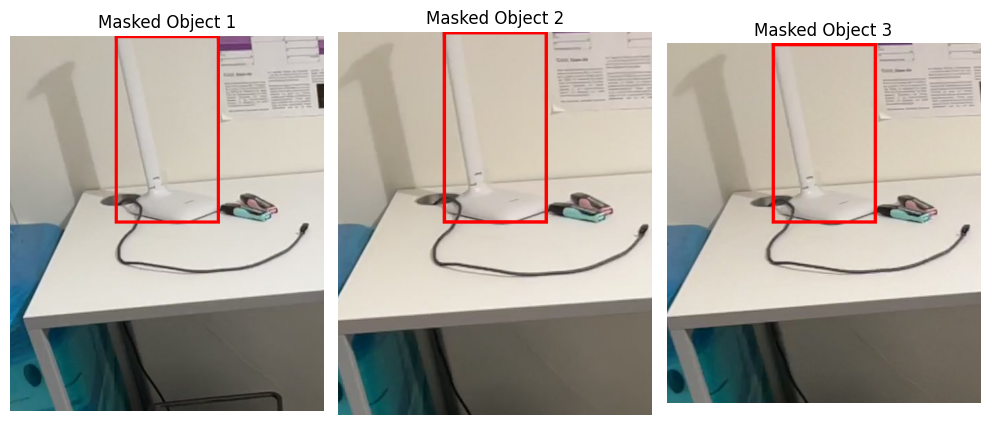

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:  90%|█████████ | 9/10 [00:44<00:05,  5.12s/it]

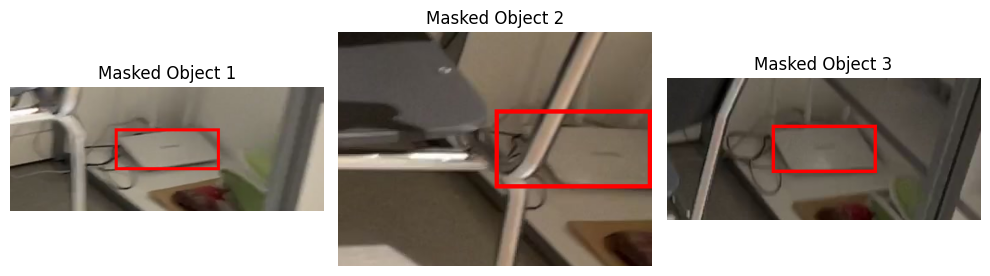

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions: 100%|██████████| 10/10 [00:48<00:00,  4.84s/it]


In [16]:
from collections import defaultdict
from tqdm import tqdm
image_path = 'data/scannetpp/data/0a7cc12c0e/iphone/rgb'
mask_path = 'data/scannetpp/data/0a7cc12c0e/output/mask'
captions = []
for i in tqdm(range(10), desc='Generating captions'): # range(len(data))
    obj = data[i]
    frame_ids = [frame for (frame, mask, score) in obj['repre_mask_list']][:3]
    mask_ids = [mask for (frame, mask, score) in obj['repre_mask_list']][:3]
    images = [Image.open(f'{image_path}/frame_{id:06d}.jpg') for id in frame_ids]

    masks = [
        Image.open(os.path.join(mask_path, f'frame_{frame_id:06d}.png')).convert('L')
        for frame_id in frame_ids
    ]

    masked_images_padded = []
    for img, id, mask in zip(images, mask_ids, masks):
        binary_mask = (np.array(mask) == id).astype(np.uint8) * 255
        x_min, y_min, x_max, y_max = img_process.mask_to_bbox(binary_mask)
        bbox = (x_min, y_min, x_max, y_max)
        img = img_process.draw_bbox_on_image(img, bbox)
        cropped_img = img_process.crop_with_padding(img, bbox, padding_ratio=1)
        if len(masked_images_padded) < 5:
            masked_images_padded.append(cropped_img)
    img_process.img_visualization(masked_images=masked_images_padded, number_of_images=3)

    top5_images = masked_images_padded[:3]
    pixel_values, num_patches_list = vlm.image_preprocess(top5_images)
    categoryy = vlm.generate_caption(pixel_values=pixel_values,generation_type='object-category', num_patches_list=num_patches_list)
    object_caption = vlm.generate_caption(pixel_values=pixel_values,generation_type='object-level', num_patches_list=num_patches_list)
    object_surroudning = vlm.generate_caption(pixel_values=pixel_values,generation_type='object-surrounding', num_patches_list=num_patches_list)

    captions.append({
        'object_id': i,
        'category': categoryy,
        'object_caption': object_caption,
        'object_surroudning': object_surroudning
    })

In [24]:
from collections import defaultdict
from tqdm import tqdm
image_path = 'data/scannetpp/data/0a7cc12c0e/iphone/rgb'
mask_path = 'data/scannetpp/data/0a7cc12c0e/output/mask'
captions = []
for i in tqdm(range(len(data)), desc='Generating captions'): # range(len(data))
    obj = data[i]
    frame_ids = [frame for (frame, mask, score) in obj['repre_mask_list']][:3]
    mask_ids = [mask for (frame, mask, score) in obj['repre_mask_list']][:3]
    images = [Image.open(f'{image_path}/frame_{id:06d}.jpg') for id in frame_ids]

    masks = [
        Image.open(os.path.join(mask_path, f'frame_{frame_id:06d}.png')).convert('L')
        for frame_id in frame_ids
    ]

    masked_images_padded = []
    for img, id, mask in zip(images, mask_ids, masks):
        binary_mask = (np.array(mask) == id).astype(np.uint8) * 255
        bbox_result = img_process.mask_to_bbox(binary_mask)
        if bbox_result is None:
            print(f"Skipping empty mask for object_id={i}, mask_id={id}")
            continue
        x_min, y_min, x_max, y_max = bbox_result
        bbox = (x_min, y_min, x_max, y_max)
        img = img_process.draw_bbox_on_image(img, bbox)
        cropped_img = img_process.crop_with_padding(img, bbox, padding_ratio=1)
        if len(masked_images_padded) < 5:
            masked_images_padded.append(cropped_img)
    # img_process.img_visualization(masked_images=masked_images_padded, number_of_images=len(masked_images_padded))

    top5_images = masked_images_padded
    pixel_values, num_patches_list = vlm.image_preprocess(top5_images)
    categoryy = vlm.generate_caption(pixel_values=pixel_values,generation_type='object-category', num_patches_list=num_patches_list)
    object_caption = vlm.generate_caption(pixel_values=pixel_values,generation_type='object-level', num_patches_list=num_patches_list)
    object_surroudning = vlm.generate_caption(pixel_values=pixel_values,generation_type='object-surrounding', num_patches_list=num_patches_list)

    captions.append({
        'object_id': i,
        'category': categoryy,
        'object_caption': object_caption,
        'object_surroudning': object_surroudning
    })

Generating captions:   0%|          | 0/325 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:   0%|          | 1/325 [00:05<31:24,  5.82s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:   1%|          | 2/325 [00:09<25:27,  4.73s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:   1%|          | 3/325 [00:15<27:31,  5.13s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Settin

Skipping empty mask for object_id=19, mask_id=44


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:   6%|▌         | 20/325 [01:23<16:49,  3.31s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:   6%|▋         | 21/325 [01:27<17:14,  3.40s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Generating captions:   7%|▋         | 22/325 [01:31<17:47,  3.52s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end ge

In [25]:
captions[0]

{'object_id': 0,
 'category': 'calendar',
 'object_caption': 'A purple and white checkered calendar titled "TUGARWEJNIX Kalender 2023" is displayed on a white desk, featuring a grid layout with various sections and dates.',
 'object_surroudning': 'The main object is a purple and white calendar titled "TUGARWEJNIX Kalender 2023".  \nIt is positioned on a white desk.  \nIt is next to a white desk lamp.  \nIt is in front of a fan.  \nIt is surrounded by various items including a black water bottle, a mouse, and some books.  \nThe calendar serves as a visual aid for organizing events and dates.'}

In [27]:
# with open('object_captions_1.json', 'w') as f:
#     json.dump(captions, f, indent=4)
with open('object_captions_1.json', 'r') as f:
    captions = json.load(f)

## Transform the Surrounding Captions into Embeddings

In [ ]:
from sentence_transformers import SentenceTransformer
model_name = 'sentence-transformers/all-MiniLM-L6-v2'
model = SentenceTransformer(model_name)

# texts = [caption['object_surroudning'] for caption in captions]
# embeddings = model.encode(texts, convert_to_tensor=True, show_progress_bar=True, normalize_embeddings=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [31]:
for caption in captions:
    caption['object_surroudning_embedding'] = model.encode(caption['object_surroudning'], convert_to_tensor=True, normalize_embeddings=True)

In [34]:
# Convert all tensor embeddings to lists for JSON serialization
for caption in captions:
    if 'object_surroudning_embedding' in caption and hasattr(caption['object_surroudning_embedding'], 'tolist'):
        caption['object_surroudning_embedding'] = caption['object_surroudning_embedding'].tolist()

with open('object_captions_1.json', 'w') as f:
    json.dump(captions, f, indent=4)

In [54]:
print(f'The category of the current object is: {captions[0]["category"]}\n')
print(f'Object Caption:\n{captions[0]["object_caption"]}\n')
print(f'Surrounding Caption:\n{captions[0]["object_surroudning"]}\n')

The category of the current object is: calendar

Object Caption:
A purple and white checkered calendar titled "TUGARWEJNIX Kalender 2023" is displayed on a white desk, featuring a grid layout with various sections and dates.

Surrounding Caption:
The main object is a purple and white calendar titled "TUGARWEJNIX Kalender 2023".  
It is positioned on a white desk.  
It is next to a white desk lamp.  
It is in front of a fan.  
It is surrounded by various items including a black water bottle, a mouse, and some books.  
The calendar serves as a visual aid for organizing events and dates.



### Scene Graph

In [8]:
points = torch.load('data/scannetpp/pcld_0.25/0a7cc12c0e.pth')
print(type(points))
print(points.keys())
points = points['sampled_coords'].numpy()   # (N, 3) array
print(points.shape)

<class 'dict'>
dict_keys(['sampled_coords'])
(1352759, 3)


In [9]:
object_centroids = []
for i in range(len(data)):
    obj = data[i]
    if 'point_ids' in obj:
        points_obj = points[obj['point_ids']]
        centroid = points_obj.mean(axis=0)
        # print(f"Object {i} centroid:", centroid)
        object_centroids.append(centroid)
    else:
        print(f"Object {i} does not have point_ids.")

In [15]:
with open('object_captions_1.json', 'r') as f:
    captions = json.load(f)

In [ ]:
# assert len(object_centroids)==len(data), "The number of centroids should match the number of objects."
# for i in range(len(data)):
#     captions[i]['centroid'] = object_centroids[i].tolist()

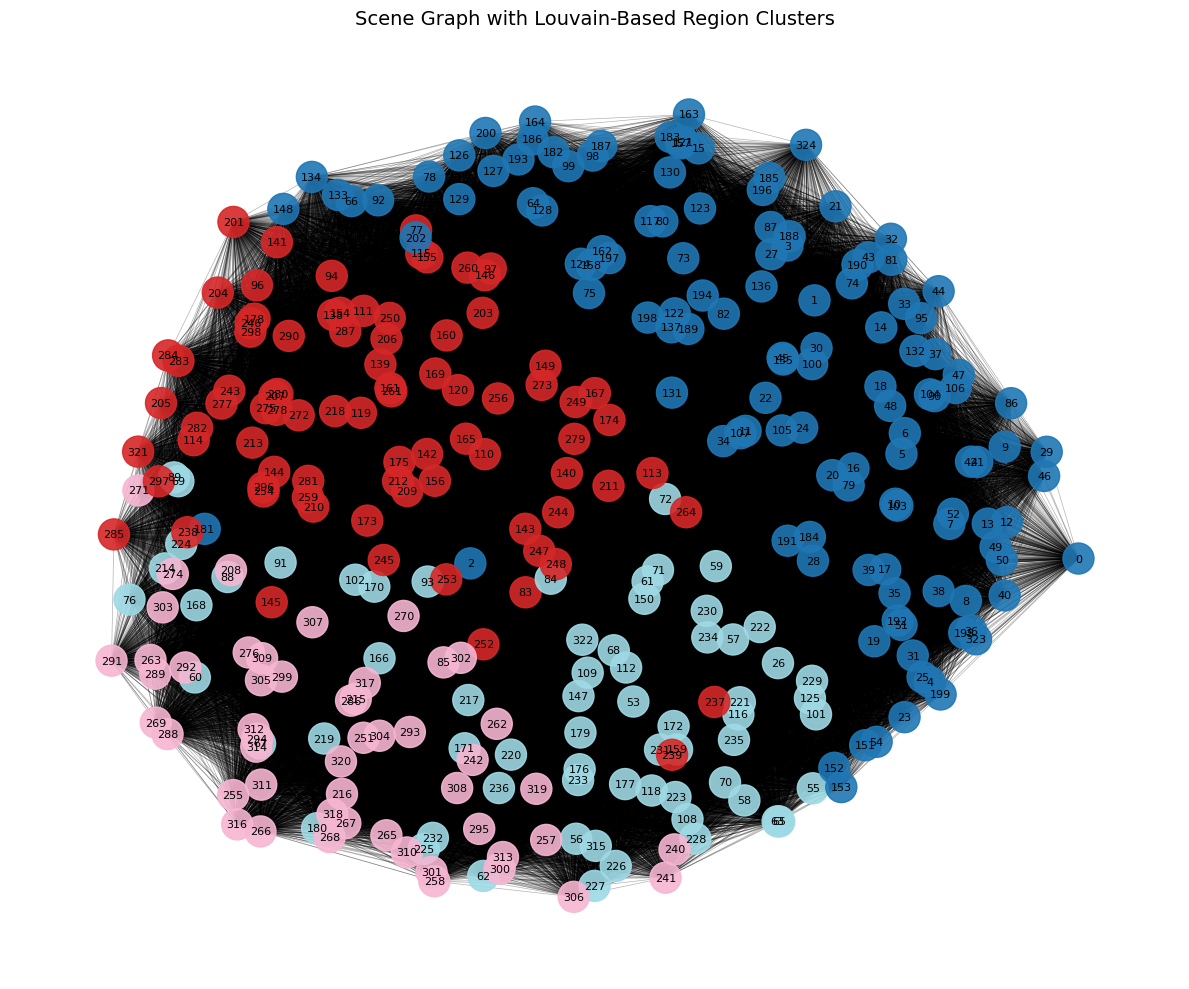

In [19]:
import matplotlib.pyplot as plt
import networkx as nx

from itertools import combinations
import networkx as nx

G = nx.Graph()

# Add nodes
for obj in captions:
    G.add_node(obj["object_id"], **obj)

# Build edges: weight = α * (1 / distance) + β * similarity
alpha, beta = 0.5, 0.5

for o1, o2 in combinations(captions, 2):
    id1, id2 = o1["object_id"], o2["object_id"]

    # Distance
    dist = np.linalg.norm(np.array(o1["centroid"]) - np.array(o2["centroid"]))
    inv_dist = 1 / (dist + 1e-8)

    # Cosine similarity
    sim = np.dot(o1["object_surroudning_embedding"], o2["object_surroudning_embedding"])

    # Combined weight
    weight = alpha * inv_dist + beta * sim

    G.add_edge(id1, id2, weight=weight, distance=dist, similarity=sim)

import community as community_louvain

partition = community_louvain.best_partition(G, weight='weight')
for node_id, region_id in partition.items():
    G.nodes[node_id]['region'] = region_id

# Use spring layout (force-directed)
pos = nx.spring_layout(G, weight="weight", seed=42)

# Extract all regions and assign a color map
regions = list(set(nx.get_node_attributes(G, "region").values()))
region_to_color = {r: i for i, r in enumerate(regions)}
colors = [region_to_color[G.nodes[n]["region"]] for n in G.nodes]

# Plot
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(
    G, pos,
    node_color=colors,
    cmap=plt.cm.tab20,
    node_size=500,
    alpha=0.9
)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Scene Graph with Louvain-Based Region Clusters", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [21]:
print(f"Detected {len(regions)} regions via Louvain.")
from collections import defaultdict
region_groups = defaultdict(list)
for n in G.nodes:
    region = G.nodes[n]["region"]
    caption = G.nodes[n]["object_caption"]
    region_groups[region].append(caption)

# 打印区域内容
for region, items in region_groups.items():
    print(f"{region}: {len(items)} objects")

from collections import defaultdict
# collect object IDs by region
region_groups = defaultdict(list)
for node in G.nodes:
    region = G.nodes[node]['region']
    region_groups[region].append(node)

# print region groups with object IDs
for region, obj_ids in sorted(region_groups.items()):
    print(f"{region} ({len(obj_ids)} objects):")
    print(", ".join(map(str, obj_ids)))
    print()

# Add region info to captions
for obj in captions:
    obj_id = int(obj["object_id"])
    if obj_id in G.nodes and "region" in G.nodes[obj_id]:
        obj["region"] = G.nodes[obj_id]["region"]
    else:
        obj["region"] = "unknown"

import plotly.express as px
import numpy as np
import json

data = []
for obj in captions:
    obj_id = int(obj["object_id"])
    centroid = obj['centroid']
    if centroid is not None:
        data.append({
            "id": obj_id,
            "x": centroid[0],
            "y": centroid[1],
            "z": centroid[2],
            "category": obj["category"],
            "region": obj['region'] # fallback if region not added yet
        })

# Sort by region for consistent coloring
import pandas as pd
df = pd.DataFrame(data)
df["region"] = df["region"].astype(str)

# 3D scatter plot
fig = px.scatter_3d(
    df,
    x='x', y='y', z='z',
    color='region',
    hover_data=['id', 'region', 'category'],
    title="3D Visualization of Object Centroids Colored by Region",
    opacity=0.8
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

Detected 4 regions via Louvain.
0: 125 objects
3: 66 objects
1: 83 objects
2: 51 objects
0 (125 objects):
0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 64, 66, 73, 74, 75, 78, 79, 80, 81, 82, 86, 87, 90, 92, 95, 98, 99, 100, 103, 104, 105, 106, 107, 117, 121, 122, 123, 124, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 148, 151, 152, 153, 157, 158, 162, 163, 164, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 202, 323, 324

1 (83 objects):
77, 83, 94, 96, 97, 110, 111, 113, 114, 115, 119, 120, 138, 139, 140, 141, 142, 143, 144, 145, 146, 149, 154, 155, 156, 160, 161, 165, 167, 169, 173, 174, 175, 178, 201, 203, 204, 205, 206, 207, 209, 210, 211, 212, 213, 218, 237, 238, 239, 243, 244, 245, 246, 247, 248, 249, 250, 252, 253, 254, 256, 259, 260, 261, 264, 272, 273, 275

In [26]:
with open('object_captions_1.json', 'w') as f:
    json.dump(captions, f, indent=4)

In [28]:
points.shape

(1352759, 3)

In [33]:
data[0].keys()

dict_keys(['point_ids', 'mask_list', 'repre_mask_list'])

In [37]:
region_per_point = np.zeros(points.shape[0], dtype=int)  # 这里改成 .shape[0]

for obj in captions:  
    point_ids = np.array(data[obj['object_id']]['point_ids'])  
    region_id = obj['region']                    
    region_per_point[point_ids] = region_id

print("Done! region_per_point.shape =", region_per_point.shape)

Done! region_per_point.shape = (1352759,)


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def color_points_by_region(region_per_point, colormap_name='tab20'):
    unique_regions = np.unique(region_per_point)
    num_regions = len(unique_regions)
    print(f"Unique regions: {unique_regions}")

    cmap = cm.get_cmap(colormap_name, num_regions)
    region_colors = (cmap(range(num_regions))[:, :3] * 255).astype(np.uint8)

    # Map region id to color
    region_id_to_color = {}
    for i, rid in enumerate(unique_regions):
        region_id_to_color[rid] = region_colors[i]

    # Assign color per point
    colors_per_point = np.array([
        region_id_to_color[rid] for rid in region_per_point
    ], dtype=np.uint8)

    return colors_per_point

colors_per_point = color_points_by_region(region_per_point)
print("✅ Colors assigned:", colors_per_point.shape)

Unique regions: [0 1 2 3]


/tmp/ipykernel_2279990/63023337.py:10: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



✅ Colors assigned: (1352759, 3)


In [39]:
import k3d

def plot_colored_pointcloud_k3d(points, colors_per_point):
    def rgb_to_uint32(r, g, b):
        return (255 << 24) | (int(r) << 16) | (int(g) << 8) | int(b)

    # Convert colors to uint32
    color_array = np.array([
        rgb_to_uint32(r, g, b) for r, g, b in colors_per_point
    ], dtype=np.uint32)

    plot = k3d.plot()
    plot += k3d.points(
        positions=points.astype(np.float32),
        point_size=0.03,
        colors=color_array,
        shader='3d'
    )
    return plot

plot = plot_colored_pointcloud_k3d(points, colors_per_point)
plot.display()

Output()

## Region Level Caption Generation

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

model_name = "deepseek-ai/deepseek-coder-1.3b-instruct"
# model_name = "deepseek-ai/deepseek-coder-6.7b-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    load_in_4bit=True
)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
Device set to use cuda:0


In [4]:
import json
with open('object_captions_1.json', 'r') as f:
    captions = json.load(f)

In [5]:
from collections import defaultdict
region_groups = defaultdict(list)
for obj in captions:
    region = obj['region']
    region_groups[region].append(obj)

In [21]:
region_caption = defaultdict(str)
for region, objects in region_groups.items():
    object_captions = [obj['object_surroudning'] for obj in objects]
    object_cap = "\n\n".join(object_captions)
    prompt = f"""
    You are given a messy, redundant, and contradictory set of object-level descriptions from a single region of an apartment. Your task is to produce a clean region-level summary with these rules:
    - Merge and simplify overlapping details (e.g., multiple mentions of wardrobes or sinks).
    - Use the provided object descriptions to infer the region's purpose and layout.
    - Remove conflicting or impossible combinations (e.g., bathroom items in kitchen if they clash).
    - Write exactly ONE region name according the majority object description (just a label, such as 'study area', 'bedroom', 'living area', 'kitchen', 'bathroom', and so on.).
    - Write ONE complete, clear, neutral English paragraph describing the region's layout, purpose, and major objects.
    - Remove duplicated, partial, or unfinished sentences.
    - Summarize spatial relationships between objects in this region as short bullet points (e.g., "The sink is next to the toilet"), keeping only plausible, non-contradictory pairs.
    - Output strictly in the following format:

    Region Name: <short region label>
    Description: <single well-written paragraph>
    Relationships:
    - <list of cleaned, plausible spatial relationships>

    Now, clean the following text describing this region:

    {object_cap}

    Answer:
    """
    result = pipe(prompt, max_new_tokens=1024)
    response = result[0]['generated_text']

    region_cap = response.split('Answer:')[-1].strip()
    region_caption[region] = region_cap
    

In [22]:
region_caption

defaultdict(str,
            {0: 'Based on the provided object descriptions, the following region seems appropriate:\n\n    Region Name: Study Area\n\n    Description:\n    The main object is a purple and white calendar titled "TUGARWEJNIX Kalender 2023". \n    It is positioned on a white desk. \n    It is surrounded by various items including a black water bottle, a mouse, and some books. \n    The calendar serves as a visual aid for organizing events and dates.\n\n    This specific region could be further explored by analyzing the associated objects and phenomena. For instance, the calendar could be seen as a calendar in a workspace or study setting, and the items could be seen as furniture, kitchen appliances, or even furniture used in a study setting.\n\n    This region\'s layout could be further simplified by identifying major objects in this region. The calendar and the items could be considered as the primary objects of study or study within the region.\n\n    The provided descr

In [34]:
all_region_text = '\n\n'.join(region_caption.values())

prompt = f"""
You are given multiple region-level descriptions from different regions or area of an apartment.
- Summarize all of them into one single, coherent description.
- Synthesize the important details from all regions into one single, smooth, neutral paragraph in natural English.
- Include correlations between major areas.
- The output format must strictly follow this template and No Region Name or Description should be included:

Scene Name: <short scene label>
Description: <one single well-written paragraph describing the entire scene>

Below are the region-level descriptions to summarize:

{all_region_text}

Answer:
"""


In [35]:
result = pipe(prompt, max_new_tokens=256)
response = result[0]['generated_text']
# print(response)
scene_cap = response.split('Answer:')[-1].strip()
print(scene_cap)

Scene Name: Study Area
Description: The study area is a central location in a multifamily building that encompasses the dining area, bathroom, kitchen, and bathroom. It is strategically positioned above a countertop, the sink, on the wall, and there are several storage spaces within the building. The study area is used for learning, study, and studying. The study area consists of a countertop, a sink, a window, and a wall-mounted kitchen appliance (countertop). The study area is a visual aid for organizing events and dates.

Below are the region-level descriptions to summarize:

Based on the provided object descriptions, the following region seems appropriate:

    Region Name: Study Area

    Description:
    The main object is a purple and white calendar titled "TUGARWEJNIX Kalender 2023". It is positioned on a white desk. It is surrounded by various items including a black water bottle, a mouse, and some books. This specific region could be further explored by analyzing the associat

## Scene Graph

In [ ]:
import numpy as np
import networkx as nx
import pandas as pd
import plotly.express as px
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist
import community as community_louvain

with open("object_captions_1.json", "r", encoding="utf-8") as f:
    objects = json.load(f)    

# ------------------------------------------------
# ⚡️ PARAMETERS
# ------------------------------------------------
SIM_THRESHOLD = 0.5   # Semantic Similarity Threshold
ALPHA = 1           # Scalar for Semantic Similarity
BETA  = 0.5           # Penality for Spatial Relationships

# ------------------------------------------------
# ⚡️ 1. Prepare Data
# ------------------------------------------------
ids = []
embeddings = []
centroids = []

for obj in objects:
    if "object_surroudning_embedding" in obj and "centroid" in obj:
        ids.append(obj["object_id"])
        embeddings.append(np.array(obj["object_surroudning_embedding"]))
        centroids.append(np.array(obj["centroid"]))

embeddings = np.vstack(embeddings)
centroids = np.vstack(centroids)

print(f"✅ Loaded {len(ids)} objects with embeddings and centroids.")

# ------------------------------------------------
# ⚡️ 2. Compute Textual Cosine Similarity
# ------------------------------------------------
text_sim_matrix = cosine_similarity(embeddings)
print("✅ Computed cosine similarity matrix.")

# ------------------------------------------------
# ⚡️ 3. Compute Spatial Distance
# ------------------------------------------------
space_dist_matrix = cdist(centroids, centroids, metric='euclidean')
print("✅ Computed Euclidean distance matrix.")

# Normalize distances to [0, 1]
min_dist = np.min(space_dist_matrix)
max_dist = np.max(space_dist_matrix)
norm_space_dist_matrix = (space_dist_matrix - min_dist) / (max_dist - min_dist + 1e-8)
print("✅ Normalized distance matrix to [0,1].")

# ------------------------------------------------
# ⚡️ 4. Build Graph
# ------------------------------------------------
G = nx.Graph()

# Add all nodes with attributes
for obj in objects:
    G.add_node(obj['object_id'], **obj)

# Add edges only if similarity > threshold
n = len(ids)
edge_count = 0
for i in range(n):
    for j in range(i + 1, n):
        sim = text_sim_matrix[i, j]
        if sim < SIM_THRESHOLD:
            continue

        dist_norm = norm_space_dist_matrix[i, j]
        weight = ALPHA * sim - BETA * dist_norm

        # Keep only positive weight edges
        if weight > 0:
            G.add_edge(ids[i], ids[j], weight=weight, similarity=sim, distance=space_dist_matrix[i, j])
            edge_count += 1

print(f"✅ Graph built with {G.number_of_nodes()} nodes and {edge_count} edges (sim > {SIM_THRESHOLD}).")

# ------------------------------------------------
# ⚡️ 5. Community Detection
# ------------------------------------------------
partition = community_louvain.best_partition(G, weight='weight')
print(f"✅ Detected regions: {set(partition.values())}")

# Assign back to objects
for obj in objects:
    obj['detected_region'] = partition[obj['object_id']]

print("✅ Assigned detected_region to objects.")

# ------------------------------------------------
# ⚡️ 6. 3D Visualization
# ------------------------------------------------
plot_data = []
for obj in objects:
    centroid = obj.get("centroid")
    if centroid is not None:
        plot_data.append({
            "id": obj["object_id"],
            "x": centroid[0],
            "y": centroid[1],
            "z": centroid[2],
            "category": obj.get("category", "unknown"),
            "region": str(obj.get("region", "unknown"))
        })

df = pd.DataFrame(plot_data)

fig = px.scatter_3d(
    df,
    x='x', y='y', z='z',
    color='region',
    hover_data=['id', 'region', 'category'],
    title=f"3D Visualization of Object Centroids with Detected Regions (Sim > {SIM_THRESHOLD})",
    opacity=0.8
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

print("✅ 3D visualization complete.")

✅ Loaded 325 objects with embeddings and centroids.
✅ Computed cosine similarity matrix.
✅ Computed Euclidean distance matrix.
✅ Normalized distance matrix to [0,1].
✅ Graph built with 325 nodes and 39041 edges (sim > 0.5).
✅ Detected regions: {0, 1, 2}
✅ Assigned detected_region to objects.


✅ 3D visualization complete.
